# Post-Rework Verification — One-Hot Removal & education/education-num Swap

`docs/REPLAN.md` §7 records a pipeline rework: one-hot encoding was removed from the PCA/t-SNE feature matrix (replaced with the pipeline's existing ordinal encoder), and the redundant-column drop was reversed to keep `education` and drop `education-num` instead. That rework's *first* run already showed PCA's explained variance roughly tripling — but that number came from a pipeline `print()` statement, not from anything re-derived independently. This notebook checks that improvement organically (rebuilding the same kind of matrix from the actual output file, not by importing pipeline code), and settles an open question from the same rework: does excluding `fnlwgt` (a census sampling weight, not a real attribute) from that matrix make a further difference — and does the *reason* originally given for why it might (its huge raw scale) actually hold up once you account for the fact that every column gets standardized before PCA ever sees it?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

PROCESSED_DIR = Path('../data/processed')

## 1. Schema re-check

Confirms the rework actually landed in the exported files: `education` should be present, `education-num` should be gone, and `pca_loadings.csv` should have shrunk from 89 one-hot feature rows down to 13 ordinal-encoded ones.

In [2]:
processed = pd.read_csv(PROCESSED_DIR / 'adult_tableau.csv')
loadings = pd.read_csv(PROCESSED_DIR / 'pca_loadings.csv', index_col=0)

print("'education' present:", 'education' in processed.columns)
print("'education-num' present:", 'education-num' in processed.columns)
print("any one-hot-looking columns (contain '_'):", any('_' in c for c in processed.columns))
print()
print("pca_loadings.csv shape:", loadings.shape, "(rows = PC1/PC2, columns = input features)")
print("loadings feature columns:", list(loadings.columns))

'education' present: True
'education-num' present: False
any one-hot-looking columns (contain '_'): False

pca_loadings.csv shape: (2, 13) (rows = PC1/PC2, columns = input features)
loadings feature columns: ['age', 'workclass', 'fnlwgt', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


## 2. Reproduce the PCA improvement independently

This rebuilds the same *kind* of matrix `preprocessing/run.py` builds (ordinal-encode the categorical columns, standard-scale everything) using a small one-off snippet here rather than importing `preprocessing/` code — consistent with how `01_findings.ipynb` avoided duplicating pipeline logic. The point is to confirm the ~24.8% combined explained variance the pipeline printed wasn't a fluke, by getting a similar number a different way.

In [3]:
feature_cols = ['age', 'workclass', 'fnlwgt', 'education', 'marital-status', 'occupation',
                'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
                'hours-per-week', 'native-country']

def build_ordinal_matrix(df, cols):
    X = df[cols].copy()
    categorical_cols = X.select_dtypes(include=['object']).columns
    for col in categorical_cols:  # loop over each categorical column, to turn its labels into number codes
        categories = sorted(X[col].dropna().unique())
        label_to_code = {label: code for code, label in enumerate(categories)}
        X[col] = X[col].map(label_to_code)
    return X

X_full = build_ordinal_matrix(processed, feature_cols)
X_full_scaled = StandardScaler().fit_transform(X_full)

pca_full = PCA(n_components=2, random_state=42)
pca_full.fit_transform(X_full_scaled)
print("Explained variance (all 13 features):", pca_full.explained_variance_ratio_)
print("Combined:", pca_full.explained_variance_ratio_.sum() * 100, "%")

Explained variance (all 13 features): [0.15610728 0.0920602 ]
Combined: 24.816748603858294 %


C:\Users\ksstu\AppData\Local\Temp\ipykernel_34872\3776472292.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


## 3. Does excluding `fnlwgt` actually matter?

The earlier finding (`docs/REPLAN.md` §5) recommended dropping `fnlwgt` from the PCA/t-SNE matrix, reasoning that its huge raw scale (12,285–1,484,705) might be diluting the variance budget. That reasoning deserves a second look: `scale_data` (`StandardScaler`) already rescales *every* column to zero mean and unit variance before PCA ever runs — so by the time PCA sees the data, `fnlwgt`'s original scale has been erased along with everyone else's. If that's right, scale can't be the mechanism, whatever the actual effect of removing `fnlwgt` turns out to be. Test both parts: (a) does removing it change the explained variance, and (b) does the scale argument hold up.

In [4]:
# confirm the scale claim directly: check fnlwgt's std before and after scaling, against another column
print("Before scaling - std of fnlwgt:", X_full['fnlwgt'].std(), " std of age:", X_full['age'].std())
print("After scaling  - std of fnlwgt:", X_full_scaled[:, feature_cols.index('fnlwgt')].std(),
      " std of age:", X_full_scaled[:, feature_cols.index('age')].std())
print()

feature_cols_no_fnlwgt = [c for c in feature_cols if c != 'fnlwgt']
X_no_fnlwgt = build_ordinal_matrix(processed, feature_cols_no_fnlwgt)
X_no_fnlwgt_scaled = StandardScaler().fit_transform(X_no_fnlwgt)

pca_no_fnlwgt = PCA(n_components=2, random_state=42)
pca_no_fnlwgt.fit_transform(X_no_fnlwgt_scaled)
print("Explained variance (12 features, fnlwgt excluded):", pca_no_fnlwgt.explained_variance_ratio_)
print("Combined:", pca_no_fnlwgt.explained_variance_ratio_.sum() * 100, "%")
print()
print("Difference in combined explained variance:",
      (pca_no_fnlwgt.explained_variance_ratio_.sum() - pca_full.explained_variance_ratio_.sum()) * 100, "percentage points")

Before scaling - std of fnlwgt: 105549.97769702224  std of age: 13.640432553581341
After scaling  - std of fnlwgt: 0.9999999999999999  std of age: 1.0



C:\Users\ksstu\AppData\Local\Temp\ipykernel_34872\3776472292.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


Explained variance (12 features, fnlwgt excluded): [0.16896191 0.09660378]
Combined: 26.5565689929325 %

Difference in combined explained variance: 1.7398203890742066 percentage points


## 4. Visual re-check

`adult_tableau.csv` already has `PC1`/`PC2`/`tSNE1`/`tSNE2` from the reworked pipeline (built on the full 13-feature ordinal matrix). Comparing these against the one-hot-era plots described in `docs/EDA.md` (fan-shaped bands for PCA, many small clusters for t-SNE) — do those one-hot artifacts persist now that one-hot is gone?

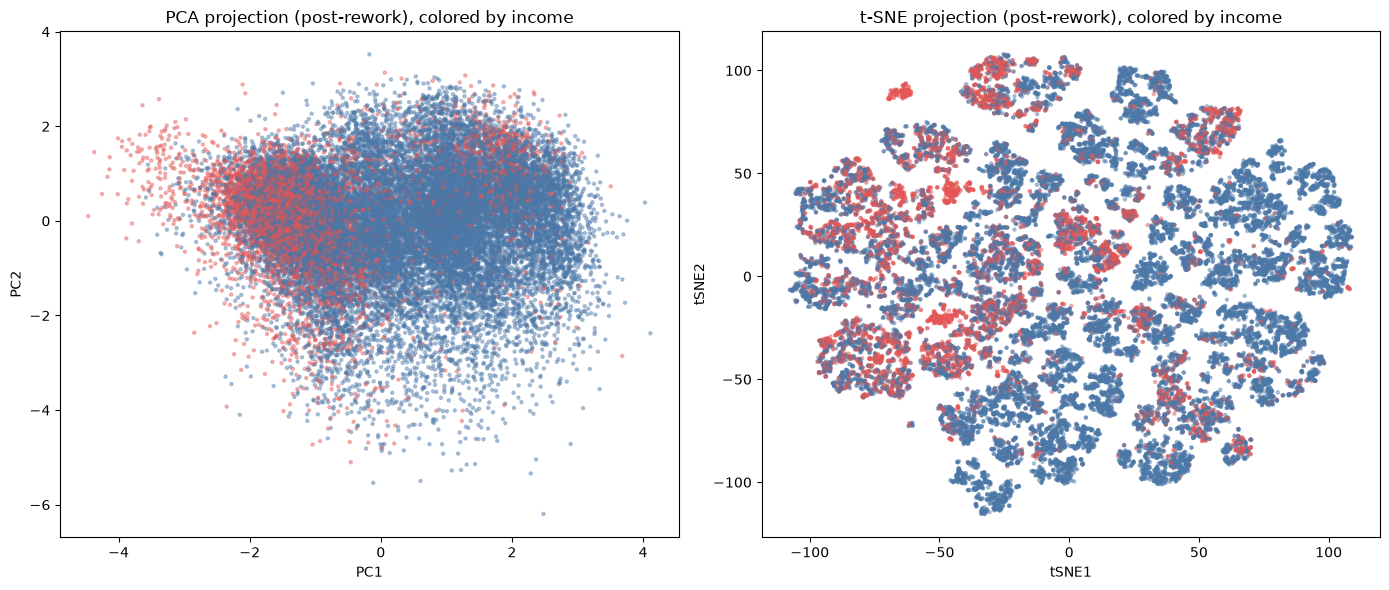

In [5]:
colors = processed['income'].map({'<=50K': '#4C78A8', '>50K': '#E45756'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(processed['PC1'], processed['PC2'], c=colors, s=5, alpha=0.4)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('PCA projection (post-rework), colored by income')

axes[1].scatter(processed['tSNE1'], processed['tSNE2'], c=colors, s=5, alpha=0.4)
axes[1].set_xlabel('tSNE1')
axes[1].set_ylabel('tSNE2')
axes[1].set_title('t-SNE projection (post-rework), colored by income')
plt.tight_layout()
plt.show()

## Summary

Full write-up of these results (with the actual numbers this run produced) lives in `docs/REPLAN.md`, not duplicated into a second `EDA.md` revision — `docs/EDA.md` stays as the first-pass write-up, and this notebook's deltas get folded into REPLAN's dated entries instead.